In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [2]:
y_test = pd.read_csv('data/y_test.csv')
hospital = pd.read_csv('data/hospital_benchmark.csv')
pd.set_option('display.max_columns', None)
#hospital.head(10)

AUC APACHE IVa: 0.8406090405707688


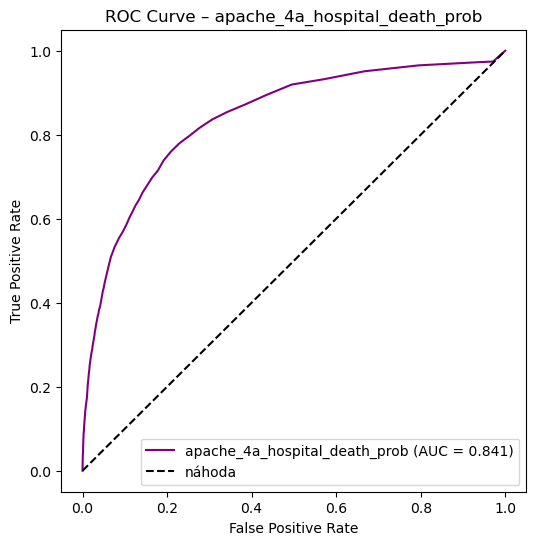

In [3]:
#benchmark roc a auc
auc_apache = roc_auc_score(y_test, hospital)
print("AUC APACHE IVa:", auc_apache)

fpr, tpr, thresholds = roc_curve(y_test, hospital)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'apache_4a_hospital_death_prob (AUC = {auc_apache:.3f})', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – apache_4a_hospital_death_prob')
plt.legend()
plt.show()

In [4]:
treshold = 0.5
hospital['hospital_death'] = (hospital['apache_4a_hospital_death_prob'] >= treshold).astype(int)
hospital.head(10)

,apache_4a_hospital_death_prob,hospital_death
0,-1.00,0
1,0.07,0
2,0.04,0
3,0.09,0
4,-1.00,0
5,0.03,0
6,0.05,0
7,0.01,0
8,0.08,0
9,0.02,0


Accuracy: 91.58%
Recall: 30.65%
Precision: 53.73%
F1: 39.03%


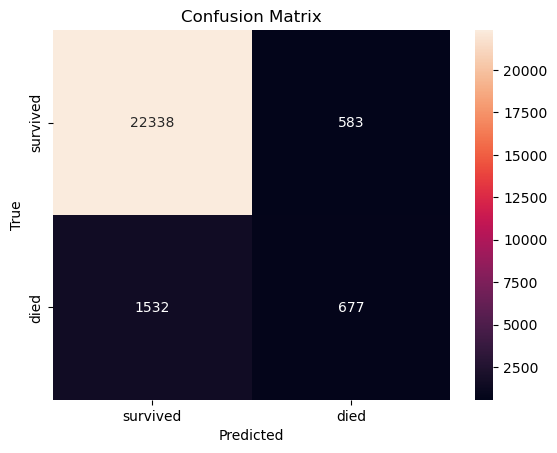

In [5]:
accuracy = accuracy_score(y_test, hospital['hospital_death'])
recall = recall_score(y_test, hospital['hospital_death'])
precision = precision_score(y_test, hospital['hospital_death'])
f1 = f1_score(y_test, hospital['hospital_death'])

print("Accuracy: %.2f%%" % (accuracy * 100.0))
print("Recall: %.2f%%" % (recall * 100.0))
print("Precision: %.2f%%" % (precision * 100.0))
print("F1: %.2f%%" % (f1 * 100.0))

matrix = confusion_matrix(y_test, hospital['hospital_death'], labels = [0, 1])
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);

In [7]:
icu = pd.read_csv('data/icu_benchmark.csv')
pd.set_option('display.max_columns', None)
icu.head(10)

,apache_4a_icu_death_prob
0,-1.00
1,0.03
2,0.04
3,0.05
4,0.03
5,0.02
6,0.02
7,0.01
8,0.03
9,0.01


AUC APACHE IVa: 0.8368789158281356


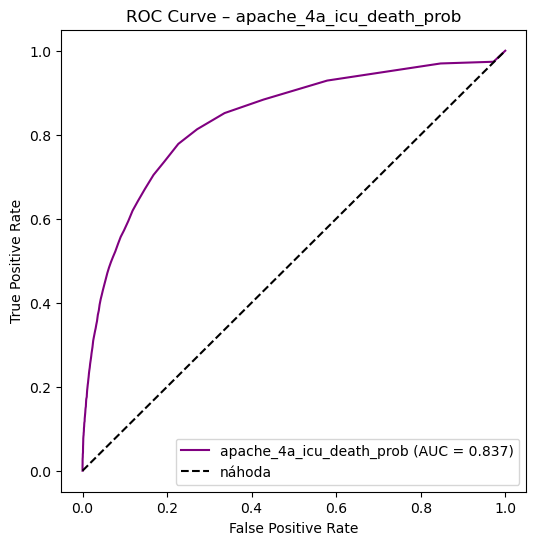

In [8]:
#benchmark roc a auc
auc_apache = roc_auc_score(y_test, icu)
print("AUC APACHE IVa:", auc_apache)

fpr, tpr, thresholds = roc_curve(y_test, icu)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'apache_4a_icu_death_prob (AUC = {auc_apache:.3f})', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – apache_4a_icu_death_prob')
plt.legend()
plt.show()

In [9]:
icu['hospital_death'] = (icu['apache_4a_icu_death_prob'] >= treshold).astype(int)
icu.head(10)

,apache_4a_icu_death_prob,hospital_death
0,-1.00,0
1,0.03,0
2,0.04,0
3,0.05,0
4,0.03,0
5,0.02,0
6,0.02,0
7,0.01,0
8,0.03,0
9,0.01,0


Accuracy: 91.89%
Recall: 19.78%
Precision: 62.16%
F1: 30.01%


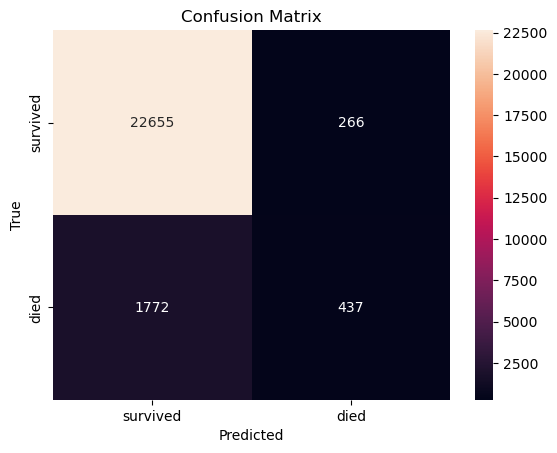

In [10]:
accuracy = accuracy_score(y_test, icu['hospital_death'])
recall = recall_score(y_test, icu['hospital_death'])
precision = precision_score(y_test, icu['hospital_death'])
f1 = f1_score(y_test, icu['hospital_death'])

print("Accuracy: %.2f%%" % (accuracy * 100.0))
print("Recall: %.2f%%" % (recall * 100.0))
print("Precision: %.2f%%" % (precision * 100.0))
print("F1: %.2f%%" % (f1 * 100.0))

matrix = confusion_matrix(y_test, icu['hospital_death'], labels = [0, 1])
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);